<h3>artools: smap(tle_string,epoch,dt,N,ANG,REF)</h3>

crea una mappa da satellite

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from artools import download_tle, tle ,smap, savetrack

In [5]:
# con questi parametri la mappa dura circa 17 minuti

SAT='ASTRA 1L'

# dt è il delta t [s] cioé il tempo tra un punto della scansione e il successivo
dt=0.7

# N è il numero di punti per ogni riga
# deve essere dispari, altrimenti gli viene aggiunto 1
N=25

# ANG è la semi-larghezza della mappa in gradi
# la mappa è "quadrata" cioè larghezza=altezza
ANG=0.4

#epoch = '2025-11-19 15:12:00'
epoch = 'NOW'

In [6]:
download_tle()
tle_string=tle(SAT)

File norad_tle.txt saved.
Reading NORAD archive...
Found at line 208
ASTRA 1L
1 31306U 07016A   26250.87003218 -.00000204  00000+0  00000+0 0  9996
2 31306   1.5287  80.7492 0004855  88.5963 106.3198  1.00272207 45816


In [7]:
# Se l'ultimo argomento (REF) è omesso o False
# non viene applicata la correzione per la rifrazione
t,mjd,az,el=smap(tle_string,epoch,dt,N,ANG,True)

N0=int((N+1)*np.floor(N/2))
print('\nn   az_sorg            el_sorg')
print(N0+1,az[N0],el[N0])

#salva nel formato della ACU
savetrack('map.txt',t,az,el)

Applying refraction correction for K band

n   az_sorg            el_sorg
313 226.78394507606913 32.983346847268


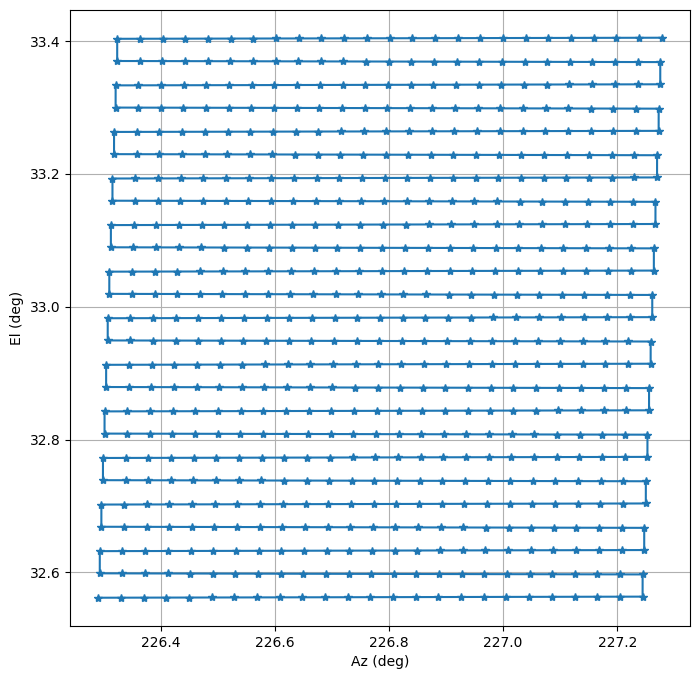

In [8]:
plt.close()  
fig = plt.figure(figsize=(8,8))  
plt.plot(az, el, '-*')  
plt.xlabel('Az (deg)')  
plt.ylabel('El (deg)')  
plt.grid() 